<a href="https://colab.research.google.com/github/AlaaBouhaouel/Langgraph/blob/main/langgragh_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''LangGraph: Building resilient and stateful multi-actor applications with LLMs.'''


#TO KNOW: def function_name(parameter: Type) -> ReturnType: So python knows the type of the parameters its dealing with
# """cc""" is a string attached to a function, accessed by print(greet.__doc__)

'LangGraph: Building resilient and stateful multi-actor applications with LLMs.'

In [ ]:
#EX01: Write a single node graph with a start and end endpoints _ LVL01

from typing import Dict, TypedDict, List # to organize the class and minimize bugs
from langgraph.graph import StateGraph # Framework that helps u design and manage the flow of tasks in ur app

In [ ]:
# Now we create an agentState - The state that will be updated and passed thru nodes til the endpoint

class AgentState(TypedDict):
  values : List[int]
  name: str
  message: str

In [ ]:


def process_vals(state: AgentState) -> AgentState:
  """Simple node that handles multiple differenr inputs"""

  state["message"] = state["name"] + ", you are doing great learning LangGraph. ue sum is " + str(sum(state['values']))
  return state



In [ ]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_vals)

graph.set_entry_point("processor")

app = graph.compile()

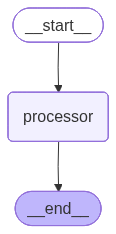

In [ ]:
# Now we will visualize the graph for more clarity

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# TESTING

result = app.invoke({"name": "Ala", "values": [23, 4, 23, 2, 0, 2]})
result["message"]


'Ala, you are doing great learning LangGraph. ue sum is 54'

In [ ]:
print (result)

{'values': [23, 4, 23, 2, 0, 2], 'name': 'Ala', 'message': 'Ala, you are doing great learning LangGraph. ue sum is 54'}


EX02

In [ ]:
from typing import Dict, List, TypedDict
from langgraph.graph import StateGraph
import math


In [ ]:
class StateAgent2(TypedDict):
  name: str
  operation: str
  message: str
  values: List[int]

In [ ]:
def processor(state: StateAgent2) -> StateAgent2:
  """Simple node that handles multiple differenr inputs"""
  x= sum(list(state["values"])) if state["operation"]=="+"  else math.prod(list(state["values"]))
  state["message"] = "Hi " + state["name"] + ", you're answer is: " + str(x)
  return state

In [ ]:
graph2 = StateGraph(StateAgent2)
graph2.add_node("proc", processor)

graph2.set_entry_point("proc")
app2 = graph2.compile()


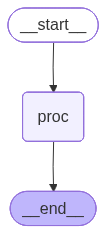

In [ ]:
# Now we will visualize the graph for more clarity

from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [ ]:
results = app2.invoke({"name": "Ala", "operation": "*", "values": [23, 4, 23, 2, 0, 2]})
results


{'name': 'Ala',
 'operation': '*',
 'message': "Hi Ala, you're answer is: 0",
 'values': [23, 4, 23, 2, 0, 2]}

EX03

In [ ]:
class AgentStating(TypedDict):
  name: str
  age: int
  skills: List[str]
  final: str


In [ ]:
def node01(state: AgentStating) -> AgentStating:
  """first node in the sequence"""
  state["final"] = f"Hi {state["name"]}"
  return state

def node02(state: AgentStating) -> AgentStating:
  """second node in the sequence"""
  state["final"] = state["final"] + f", you are {state["age"]} years old"
  return state

def node03(state : AgentStating) -> AgentStating:
  """Third node in the sequence"""
  state["final"] += " and you are greate at "
  state["final"] += " , ".join(list(state["skills"]))
  return state



In [ ]:
graph3= StateGraph(AgentStating)
graph3.add_node("node01", node01)
graph3.add_node("node02", node02)
graph3.add_node("node03", node03)


#SET ENTRY POINT
graph3.set_entry_point("node01")

#SET AN EDGES
graph3.add_edge("node01", "node02")
graph3.add_edge("node02", "node03")



app3 = graph3.compile()

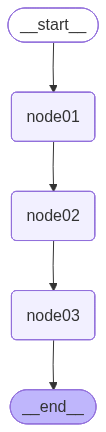

In [ ]:

from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [ ]:
results = app3.invoke({"name": "Ala", "age": 34, "skills": ["coding", "dancing", "cooking muffins"]})
results

{'name': 'Ala',
 'age': 34,
 'skills': ['coding', 'dancing', 'cooking muffins'],
 'final': 'Hi Ala, you are 34 years old and you are greate at coding , dancing , cooking muffins'}

EX4


In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
class AgentStarter(TypedDict):
  n1: int
  n2: int
  op: str
  answer: str
  sign: str


In [ ]:
def addition(state: AgentStarter) -> AgentStarter:
  """This node will perform simple addition in the graph"""

  state["answer"] = str(state["n1"] + state["n2"])
  return state

def substraction(state: AgentStarter) -> AgentStarter:
  """This node will perform simple substraction in the graph"""

  state["answer"] = str(state["n1"] - state["n2"])
  return state

def multiplication(state: AgentStarter) -> AgentStarter:
  """This node will perform simple multiplication in the graph"""

  state["answer"] = str(state["n1"] * state["n2"])
  return state

def division(state: AgentStarter) -> AgentStarter:
  """This node will perform simple division in the graph"""

  state["answer"] = str(state["n1"] / state["n2"])
  return state



In [ ]:
def decider(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  if state["op"] == "+":
    return "addition_operation"
  elif state["op"] == "-":
    return "substraction_operation"
  elif state["op"] == "*":
    return "multiplication_operation"
  elif state["op"] == "/":
    return "division_operation"
  else:
    raise ValueError(f"Invalid operation: {state['op']}")

In [ ]:
graph = StateGraph(AgentStarter)

# A pass-through node that simply returns the current state
def pass_through(state: AgentStarter) -> AgentStarter:
    return state

#Graph Nodes : their names
graph.add_node("start_point", pass_through) # New entry point node
graph.add_node("addition_node", addition)
graph.add_node("substraction_node", substraction)
graph.add_node("multiplication_node", multiplication)
graph.add_node("division_node", division)

#SET ENTRY POINTS
graph.set_entry_point("start_point") # Set the new pass_through node as the entry point

#SET EDGES
# START implicitly connects to the entry point, no explicit edge needed
graph.add_conditional_edges(
    "start_point", # Conditional edges now originate from the pass_through node
    decider,       # The decider function is used as the condition for routing
    {
        "addition_operation": "addition_node",
        "substraction_operation": "substraction_node",
        "multiplication_operation": "multiplication_node",
        "division_operation": "division_node"
    }
)

graph.add_edge("addition_node", END)
graph.add_edge("substraction_node", END)
graph.add_edge("multiplication_node", END)
graph.add_edge("division_node", END)

app = graph.compile()

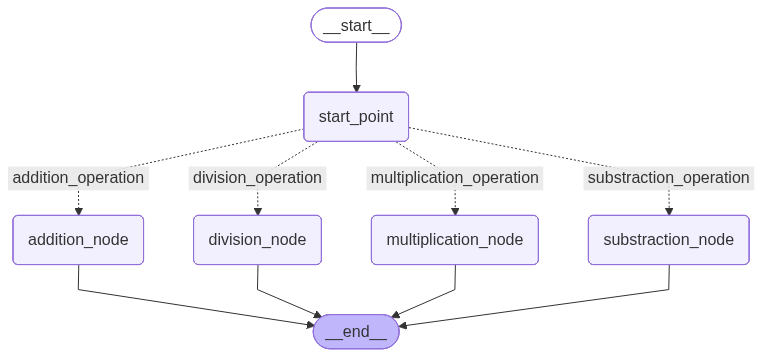

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {"n1": 10, "n2": 5, "op": "+"}
results = app.invoke(initial_state)
results

{'n1': 10, 'n2': 5, 'op': '+', 'answer': '15'}

EX05: Multiple conditioned routers

In [ ]:
#SAME AS THE LAST EXERCISE WITH THIS END

def decider2(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  if "answer" not in state:
    return "error: The first router did not get an answer!"
  else:
    if state["answer"]> 0:
      return "positive"
    else:
      return "negative"

In [ ]:
def positive_node(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  state["sign"] = "positive"
  return state

def negative_node(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  state["sign"] = "negative"
  return state



In [ ]:
graph = StateGraph(AgentStarter)

# A pass-through node that simply returns the current state
def pass_through(state: AgentStarter) -> AgentStarter:
    return state

#Graph Nodes : their names
graph.add_node("router1", pass_through) # New entry point node
graph.add_node("addition_node", addition)
graph.add_node("substraction_node", substraction)
graph.add_node("multiplication_node", multiplication)
graph.add_node("division_node", division)
graph.add_node("router2", pass_through) # New entry point node
graph.add_node("positive_node", positive_node)
graph.add_node("negative_node", negative_node)



#SET ENTRY POINTS
graph.set_entry_point("router1") # Set the new pass_through node as the entry point

#SET EDGES
# START implicitly connects to the entry point, no explicit edge needed
graph.add_conditional_edges(
    "router1", # Conditional edges now originate from the pass_through node
    decider,       # The decider function is used as the condition for routing
    {
        "addition_operation": "addition_node",
        "substraction_operation": "substraction_node",
        "multiplication_operation": "multiplication_node",
        "division_operation": "division_node"
    }
)
graph.add_conditional_edges(
    "router2", # Conditional edges now originate from the pass_through node
    decider2,       # The decider function is used as the condition for routing
    {
        "positive": "positive_node",
        "negative": "negative_node"
    }
)

graph.add_edge("addition_node","router2")
graph.add_edge("substraction_node","router2")
graph.add_edge("multiplication_node","router2")
graph.add_edge("division_node","router2")




graph.add_edge("positive_node", END)
graph.add_edge("negative_node", END)


app = graph.compile()

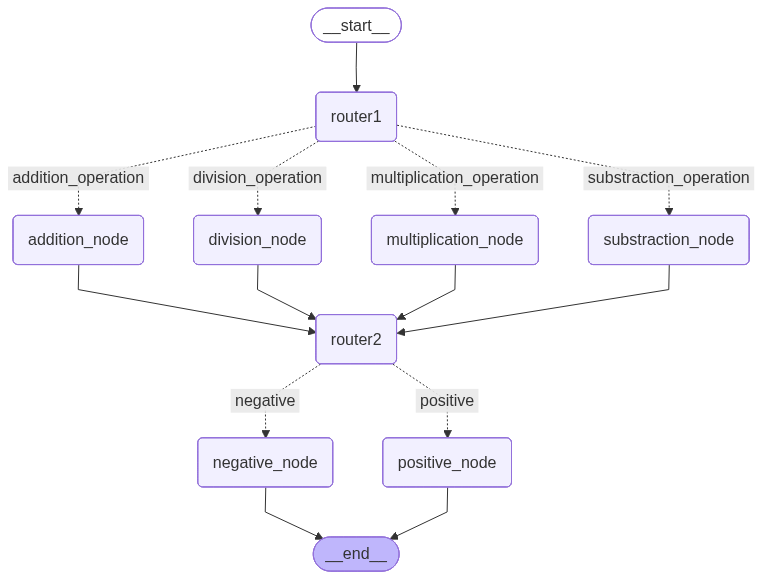

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

EX06: LOOPING GRAPH

In [ ]:
import random

In [ ]:
class Agentstart(TypedDict):
  name: str
  n: List[int]
  counter: int


In [ ]:
def greeting_node(state: Agentstart) -> Agentstart:
  state["name"] = f"Hi {state['name']}!"
  state["counter"] = 0
  return state

In [ ]:
def random_node(state: Agentstart) -> Agentstart:
  state["n"].append(random.randint(0, 10))
  state["counter"] +=1
  return state

In [ ]:
def should_continue(state: Agentstart) -> Agentstart:
  if state["counter"] < 5:
    return "loop"
  else:
    return "exit"

In [ ]:
graph = StateGraph(Agentstart)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge("greeting", "random")


graph.add_conditional_edges(
    "random", #source node
    should_continue, #decider function
    {
        "loop": "random", #first way
        "exit": END #Second way
    }
)

graph.set_entry_point("greeting")
app = graph.compile()

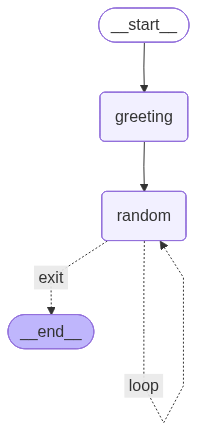

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
res = app.invoke({"name": "Ala", "n": [], "couter": -1})
res

{'name': 'Hi Ala!', 'n': [10, 3, 0, 2, 9], 'counter': 5}

EX07

In [ ]:
#This is a game: AUTOMATIC HIGHER OR LOWER GAME

#Bounds: 1 - 20
#Max Number of Guesses : 7
#Loop until max or succeess

#After each guess, the hint node should say "HIGHER" or "LOWER"
#INPUT : Player_name, guesses list, attempts, lower_bound, upper_bond
#After every guess, the bounds get adjusted

In [ ]:
class GameAgent(TypedDict):
  player: str
  x : int
  guesses: List[int]
  attempts: int
  lower_bound: int
  upper_bound: int
  win: bool

In [ ]:
def setup_node(state: GameAgent) -> GameAgent:
  state["guesses"] = []
  state["attempts"] = 0
  state["lower_bound"] = 1
  state["upper_bound"] = 20
  state["x"] = random.randint(state["lower_bound"], state["upper_bound"])
  return state


In [ ]:
def guess_node(state: GameAgent) -> GameAgent:
  print("guessing ..")
  guess = random.randint(state["lower_bound"], state["upper_bound"])
  print(state)
  state["guesses"].append(guess)
  print("Guess : "+ str(guess))
  return state


In [ ]:
def update(state: GameAgent) -> GameAgent:
  print("Updating ..")
  state["attempts"] += 1

  if state["guesses"][-1] > state["x"]:
    state["upper_bound"] = state["guesses"][-1]
    print(f"not exactly ...")
    return state

  if state["guesses"][-1] < state["x"]:
    state["lower_bound"] = state["guesses"][-1]
    print(f"not exactly ...")
    return state
  return state


In [ ]:
def decider_node(state: GameAgent) -> str:
  print("Deciding ..")

  if state["guesses"][-1] == state["x"]: #success
    print("Success")
    return "end"

  if state["attempts"] >= 7: #Out of Attempts
    print("Out of Attempts")
    return "end"

  return "continue"


In [ ]:
graph = StateGraph(GameAgent)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("update", update)

graph.add_edge("setup", "guess")
graph.add_edge("guess", "update")

graph.add_conditional_edges(
    "update", #source node
    decider_node, #decider function
    {
        "continue": "guess", #first way
        "end": END #Second way
    }
)

graph.set_entry_point("setup")
app = graph.compile()

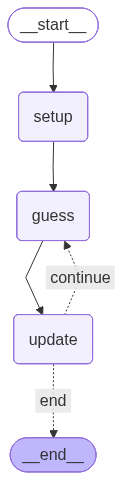

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
results = app.invoke({
  "player": "Ala",
  "attempts": 0,
  "lower_bound": 0,
  "upper_bound": 20,
  "guesses": [],
  "x": 0,
  "win": False
})

guessing ..
{'player': 'Ala', 'x': 0, 'guesses': [], 'attempts': 0, 'lower_bound': 0, 'upper_bound': 20, 'win': False}
Guess : 1
Deciding ..
not exactly ; [1]
guessing ..
{'player': 'Ala', 'x': 0, 'guesses': [1], 'attempts': 1, 'lower_bound': 0, 'upper_bound': 20, 'win': False}
Guess : 18
Deciding ..
not exactly ; [1, 18]
guessing ..
{'player': 'Ala', 'x': 0, 'guesses': [1, 18], 'attempts': 2, 'lower_bound': 0, 'upper_bound': 20, 'win': False}
Guess : 10
Deciding ..
not exactly ; [1, 18, 10]
guessing ..
{'player': 'Ala', 'x': 0, 'guesses': [1, 18, 10], 'attempts': 3, 'lower_bound': 0, 'upper_bound': 20, 'win': False}
Guess : 11
Deciding ..
not exactly ; [1, 18, 10, 11]
guessing ..
{'player': 'Ala', 'x': 0, 'guesses': [1, 18, 10, 11], 'attempts': 4, 'lower_bound': 0, 'upper_bound': 20, 'win': False}
Guess : 7
Deciding ..
not exactly ; [1, 18, 10, 11, 7]
guessing ..
{'player': 'Ala', 'x': 0, 'guesses': [1, 18, 10, 11, 7], 'attempts': 5, 'lower_bound': 0, 'upper_bound': 20, 'win': False}
